### Unsupervised learning and clustering
- K-means clustering and hierachical clustering


### What is unsupervised learning?
### Supervised vs Unsupervised
|Supervised | Unsupervised |
|--- | --- |
| Training data has labels | Training data has no labels |
|Goal: Learn a mapping from inputs to outputs | Goal: Find the hidden structure and patterns in the data.|
|Example use cases: Spam detection, house prices prediction, cancer diagnosis | Examples: customer segmentation, anomally detection |

### K-means clustering
### How K-means work

## The elbow method. How do we choose K?


In [1]:
import numpy as np
np.random.seed(42)

In [2]:
import pandas as pd
n = 300
customers = pd.DataFrame({
'annual_spend': np.r_[
np.random.normal(2000, 400, 75), # Low spenders
np.random.normal(5000, 600, 75), # Mid spenders
np.random.normal(9000, 800, 75), # High spenders
np.random.normal(3500, 500, 75), # Occasional spenders
],
'visit_frequency': np.r_[
np.random.normal(5, 2, 75),
np.random.normal(20, 4, 75),
np.random.normal(35, 5, 75),
np.random.normal(10, 3, 75),
],
'avg_basket_size': np.r_[
np.random.normal(100, 20, 75),
np.random.normal(250, 40, 75),
np.random.normal(400, 60, 75),
np.random.normal(180, 30, 75),
]
})


In [3]:
customers.shape


(300, 3)

In [4]:
customers.describe()

,annual_spend,visit_frequency,avg_basket_size
count,300.000000,300.000000,300.000000
mean,4885.579731,17.353446,235.944201
std,2737.409873,11.860590,119.455913
min,952.101958,2.103831,46.062267
25%,2623.196753,6.942315,139.404969
50%,4183.307697,13.467304,214.169988
75%,6735.005912,27.350387,316.928797
max,12082.185193,50.394404,557.942924


In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   annual_spend     300 non-null    float64
 1   visit_frequency  300 non-null    float64
 2   avg_basket_size  300 non-null    float64
dtypes: float64(3)
memory usage: 7.2 KB


In [6]:
customers.head()

,annual_spend,visit_frequency,avg_basket_size
0,2198.685661,3.342010,115.139772
1,1944.694280,3.879638,81.556694
2,2259.075415,6.494587,117.392118
3,2609.211943,6.220741,127.112757
4,1906.338650,4.958197,108.268698


In [7]:
#scaling data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customers)

In [8]:
# elbow method - finding the best number of clusters (K)
from sklearn.cluster import KMeans
inertias = []

for k in range (1, 11):
    km = KMeans (n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

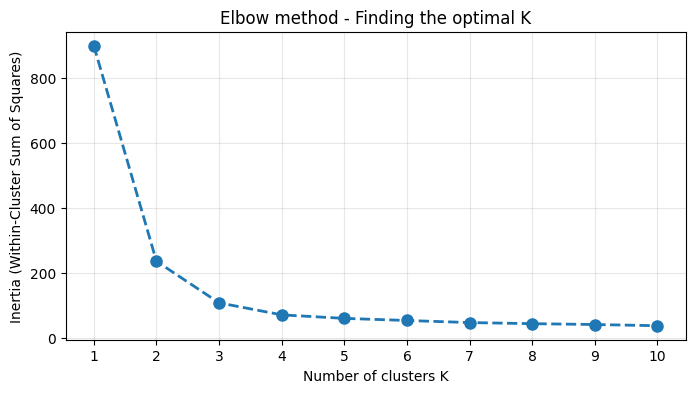

In [9]:
#Plotting the elbow curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, 'o--', linewidth=2, markersize=8)
 
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow method - Finding the optimal K')
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()


In [10]:
km_final =KMeans(n_clusters=4, random_state=42, n_init=10)
customers['cluster'] = km_final.fit_predict(X_scaled)
customers

,annual_spend,visit_frequency,avg_basket_size,cluster
0,2198.685661,3.342010,115.139772,2
1,1944.694280,3.879638,81.556694,2
2,2259.075415,6.494587,117.392118,2
3,2609.211943,6.220741,127.112757,2
4,1906.338650,4.958197,108.268698,2
...,...,...,...,...
295,3153.545202,8.469951,199.461297,3
296,3949.799938,9.190375,174.986458,3
297,3653.649760,7.063709,184.401411,3
298,3906.431059,8.667120,216.195269,3


In [11]:
# import os
# os.environ["OMP_NUM_THREADS"] = "2"
# import warnings
# warnings.filterwarnings("ignore")

In [12]:
#profile for each cluster
profile = customers.groupby('cluster').agg({
'annual_spend': 'mean',
'visit_frequency': 'mean',
'avg_basket_size': 'mean',
'cluster': 'count'
}).rename(columns={'cluster': 'count'}).round(0)
 
print(" Cluster profiles")
print(profile)



 Cluster profiles
         annual_spend  visit_frequency  avg_basket_size  count
cluster                                                       
0              5004.0             20.0            249.0     70
1              9125.0             35.0            409.0     75
2              1954.0              5.0            100.0     75
3              3556.0             10.0            189.0     80


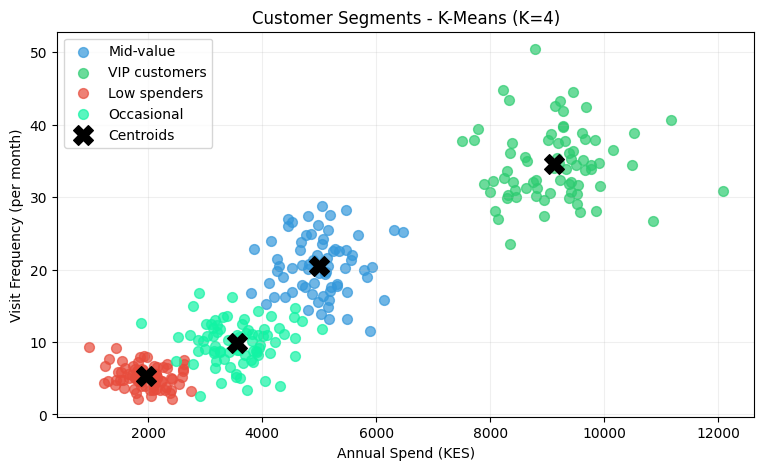

In [13]:
colours = [ '#3498db','#2ecc71', '#e74c3c', "#12f3a4"]
labels = ['Mid-value','VIP customers', 'Low spenders' , 'Occasional']

plt.figure(figsize=(9, 5))
for c in range(4):
    mask = customers['cluster'] == c
    plt.scatter(
    customers[mask]['annual_spend'],
    customers[mask]['visit_frequency'],
    c=colours[c],
    label= labels[c],
    alpha=0.7,
    s=50
)
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(
    centroids_orig[:, 0], 
    centroids_orig[:, 1],
    s = 200, 
    marker = 'X', 
    c = 'black', 
    zorder = 5, 
    label = 'Centroids'
)
 
plt.xlabel('Annual Spend (KES)')
plt.ylabel('Visit Frequency (per month)')
plt.title('Customer Segments - K-Means (K=4)')
plt.legend()
plt.grid(alpha = 0.2)

### Hierachical clustering
### How is it different from k- means
- Does not require choosing K upfront
- builds a complete tree of nested clusters
- lets is decide the number of clusters after seeing the structure


## Agglomerative clustering
### steps
1. Start with all points separate:
Treat each data point as its own cluster like A, B, C, ...
Initially, you have n clusters for n data points.
2. Compute pairwise distances:
Calculate the distance between every pair of clusters.
Common choices include Euclidean, Manhattan or Cosine distance.
Store these values in a distance matrix.
To know more about them refer to: Measures of Distance
3. Merge the nearest clusters:
Identify the two clusters that are closest based on the chosen linkage method such as single, complete, average or Ward linkage.
Combine them into a single new cluster.
4. Update distances:
Recalculate the distances between the newly formed cluster and all remaining clusters.
Use the same linkage rule to ensure consistency.
5. Repeat the process:
Continue merging clusters and updating distances iteratively.
Stop when you reach a predefined number of clusters (k) or a distance threshold.
6. Visualize the results:
Create a dendrogram to visualize how clusters merged at each step.
Choose a suitable cut on the dendrogram to obtain the final cluster groups.


### Linkage methods - how we measure the distance between clusters
1. Ward.
2. Complete.
3. Single
4. Average

### Where to use hierachical
- When you don't know the number of clusters
- when you want cluster hierachy insight
- Dataset is small to medium
- When you want interpretable structure

In [14]:
# Picking a subset of 60 customers for readability
import numpy as np
subset_ids = np.random.choice(len(X_scaled),60, replace = False)
X_sub = X_scaled[subset_ids]

In [15]:
# Linkage method
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_sub,method = 'ward' )

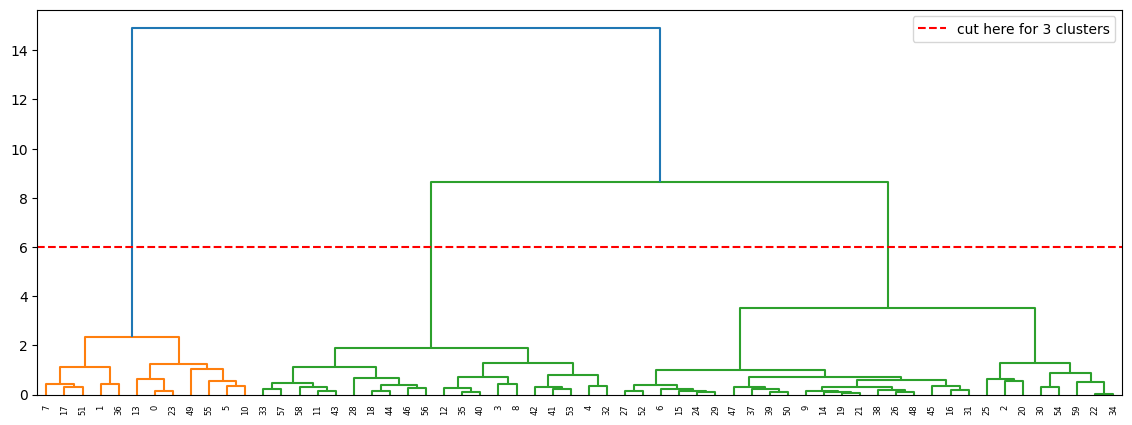

In [16]:
# plot dendogram
import matplotlib.pyplot as plt

plt.figure (figsize= (14, 5))
dendrogram (Z, truncate_mode= 'level')
plt.axhline(y=6, c="red", linestyle = '--', linewidth = 1.5, label = 'cut here for 3 clusters')
plt.legend()
plt.show()

In [17]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 4, linkage = 'ward')
customers ['hc_cluster'] = hc.fit_predict(X_scaled)
customers

,annual_spend,visit_frequency,avg_basket_size,cluster,hc_cluster
0,2198.685661,3.342010,115.139772,2,3
1,1944.694280,3.879638,81.556694,2,3
2,2259.075415,6.494587,117.392118,2,3
3,2609.211943,6.220741,127.112757,2,3
4,1906.338650,4.958197,108.268698,2,3
...,...,...,...,...,...
295,3153.545202,8.469951,199.461297,3,1
296,3949.799938,9.190375,174.986458,3,1
297,3653.649760,7.063709,184.401411,3,1
298,3906.431059,8.667120,216.195269,3,1


In [18]:
print('k-means cluster profiles')
print(customers.groupby('cluster')[['annual_spend','visit_frequency']].mean().round(0))

k-means cluster profiles
         annual_spend  visit_frequency
cluster                               
0              5004.0             20.0
1              9125.0             35.0
2              1954.0              5.0
3              3556.0             10.0


In [19]:
print('Hierachical cluster profiles')
print(customers.groupby('hc_cluster')[['annual_spend', 'visit_frequency']].mean ().round(0))

Hierachical cluster profiles
            annual_spend  visit_frequency
hc_cluster                               
0                 9125.0             35.0
1                 3509.0             10.0
2                 4994.0             20.0
3                 1954.0              5.0


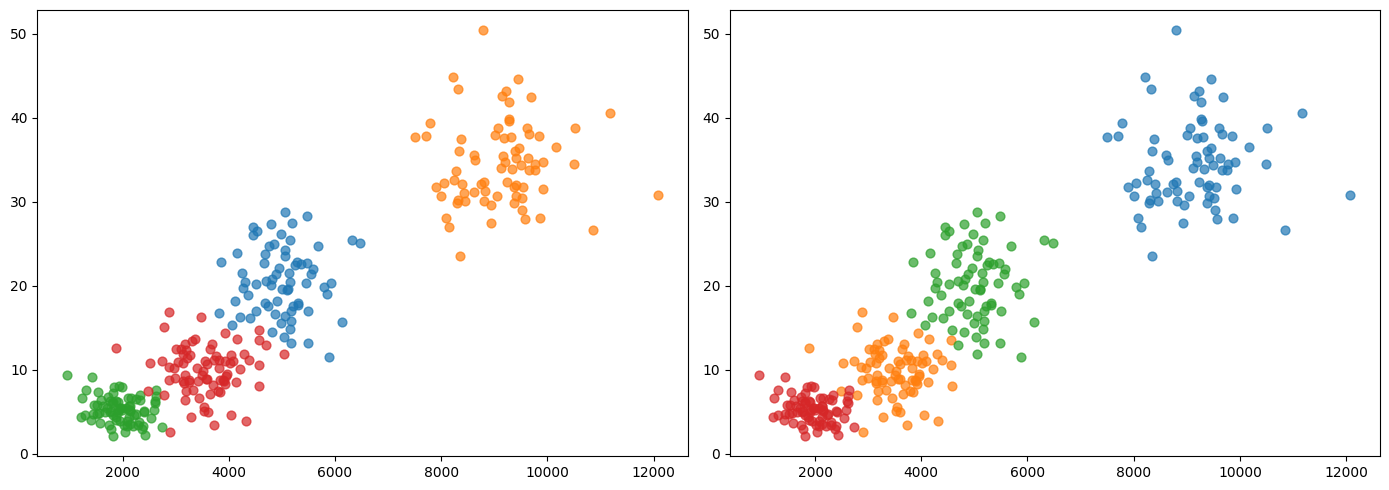

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['cluster', 'hc_cluster'],
    ['K-means cluster', 'Hierarchical clusters']
):
    for c in range(4):
        mask = customers[col] == c
        ax.scatter(
            customers[mask]['annual_spend'],
            customers[mask]['visit_frequency'],
            alpha=0.7, s=40, label=f'cluster {c}'
        )
   

plt.tight_layout()
plt.show()     
     